In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
GT_FILE = "test_data.csv"

# Đọc file gốc
df_gt = pd.read_csv(GT_FILE)
df_gt.dropna(subset=['commonsense'],inplace=True, how = "any")
total_original_samples = len(df_gt)

# Tìm các index hợp lệ (commonsense KHÔNG bị null)
valid_indices = df_gt[df_gt['commonsense'].notnull()].index

# Lọc Ground Truth theo index hợp lệ
df_gt = df_gt.loc[valid_indices].copy()
df_gt['sarcasm_type'] = df_gt['sarcasm_type'].fillna('Non-Sarcastic')

print(f"Tổng số mẫu gốc ban đầu: {total_original_samples}")
print(f"Số mẫu sau khi loại bỏ null commonsense: {len(df_gt)}")

# Lưu lại mảng nhãn gốc để đánh giá
y_true_label = df_gt['sarcasm_label'].values
y_true_type = df_gt['sarcasm_type'].values

Tổng số mẫu gốc ban đầu: 787
Số mẫu sau khi loại bỏ null commonsense: 787


In [4]:
# Cấu trúc: "Tên Model": {"file": "tên_file.csv", "label_col": "cột_nhị_phân", "type_col": "cột_đa_lớp"}
MODELS_TO_EVALUATE = {
    # Baselines truyền thống
    "PhoBERT": {"file": "test_result_PhoBERT_FINAL.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "XLM-RoBERTa": {"file": "test_result_XLM_Roberta_FINAL.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "SVM+TF-IDF": {"file": "test_result_SVM_FINAL.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    
    # Qwen A22B Prompting
    "Qwen-A22B (Zero)": {"file": "Qwen3_A22B_zero-shot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "Qwen-A22B (Few)": {"file": "Qwen3_A22B_few-shot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "Qwen-A22B (CoT)": {"file": "Qwen3_A22B_cot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "Qwen-A22B (Combine)": {"file": "Qwen3_A22B_combine.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    
    # LLaMA 70B Prompting
    "LLaMA-70B (Zero)": {"file": "LLama3.3_70B_zero-shot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "LLaMA-70B (Few)": {"file": "LLama3.3_70B_few-shot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "LLaMA-70B (CoT)": {"file": "LLama3.3_70B_cot.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    "LLaMA-70B (Combine)": {"file": "LLama3.3_70B_combine.csv", "label_col": "sarcasm_label", "type_col": "sarcasm_type"},
    
    # Distillation (Đã fine-tune)
    "Qwen-3B (Distilled)": {"file": "test_result_3B.csv", "label_col": "predicted_label", "type_col": "predicted_type"},
    "Qwen-7B (Distilled)": {"file": "test_result_7B.csv", "label_col": "predicted_label", "type_col": "predicted_type"},
    "Qwen-14B (Distilled)": {"file": "test_result_14B.csv", "label_col": "predicted_label", "type_col": "predicted_type"},
}

predictions_label = {}
predictions_type = {}

print("=== LOAD DỮ LIỆU CÁC MÔ HÌNH ===")
for model_name, config in MODELS_TO_EVALUATE.items():
    try:
        # Tải file lên
        df_model = pd.read_csv(config["file"])
        df_model.dropna(subset=['commonsense'],inplace=True,how="any")
        # Chỉ giữ lại đúng các hàng có index nằm trong `valid_indices` đã lọc
        df_model_filtered = df_model.loc[valid_indices].copy()
        
        # Xử lý nhãn Type (Điền Non-Sarcastic cho các giá trị nan/None)
        y_pred_type = df_model_filtered[config["type_col"]].fillna('Non-Sarcastic')
        y_pred_type = y_pred_type.replace(['None', 'none', 'NaN'], 'Non-Sarcastic')
        
        # Lưu vào dict
        predictions_label[model_name] = df_model_filtered[config["label_col"]].values
        predictions_type[model_name] = y_pred_type.values
        
        print(f"✅ Đã tải thành công: {model_name} (Số lượng: {len(df_model_filtered)})")
    except Exception as e:
        print(f"❌ Lỗi xử lý {model_name}: {e}")

=== LOAD DỮ LIỆU CÁC MÔ HÌNH ===
✅ Đã tải thành công: PhoBERT (Số lượng: 787)
✅ Đã tải thành công: XLM-RoBERTa (Số lượng: 787)
✅ Đã tải thành công: SVM+TF-IDF (Số lượng: 787)
✅ Đã tải thành công: Qwen-A22B (Zero) (Số lượng: 787)
✅ Đã tải thành công: Qwen-A22B (Few) (Số lượng: 787)
✅ Đã tải thành công: Qwen-A22B (CoT) (Số lượng: 787)
✅ Đã tải thành công: Qwen-A22B (Combine) (Số lượng: 787)
✅ Đã tải thành công: LLaMA-70B (Zero) (Số lượng: 787)
✅ Đã tải thành công: LLaMA-70B (Few) (Số lượng: 787)
✅ Đã tải thành công: LLaMA-70B (CoT) (Số lượng: 787)
✅ Đã tải thành công: LLaMA-70B (Combine) (Số lượng: 787)
✅ Đã tải thành công: Qwen-3B (Distilled) (Số lượng: 787)
✅ Đã tải thành công: Qwen-7B (Distilled) (Số lượng: 787)
✅ Đã tải thành công: Qwen-14B (Distilled) (Số lượng: 787)



 BÁO CÁO ĐÁNH GIÁ: SARCASM LABEL BINARY (N=787)
               Model  Accuracy  Macro-F1  Macro-Precision  Macro-Recall
             PhoBERT  0.918679  0.738972         0.714089      0.773603
         XLM-RoBERTa  0.841169  0.649468         0.621992      0.771439
          SVM+TF-IDF  0.641677  0.519374         0.576930      0.774845
    Qwen-A22B (Zero)  0.329098  0.304845         0.543232      0.621990
     Qwen-A22B (Few)  0.312579  0.293296         0.548414      0.628944
     Qwen-A22B (CoT)  0.508259  0.424657         0.547102      0.671089
 Qwen-A22B (Combine)  0.439644  0.382189         0.545803      0.657857
    LLaMA-70B (Zero)  0.682338  0.518581         0.553847      0.677771
     LLaMA-70B (Few)  0.734435  0.536893         0.551691      0.650348
     LLaMA-70B (CoT)  0.632783  0.482606         0.538872      0.635152
 LLaMA-70B (Combine)  0.744600  0.535543         0.547395      0.632030
 Qwen-3B (Distilled)  0.870394  0.673747         0.641085      0.763410
 Qwen-7B (Disti

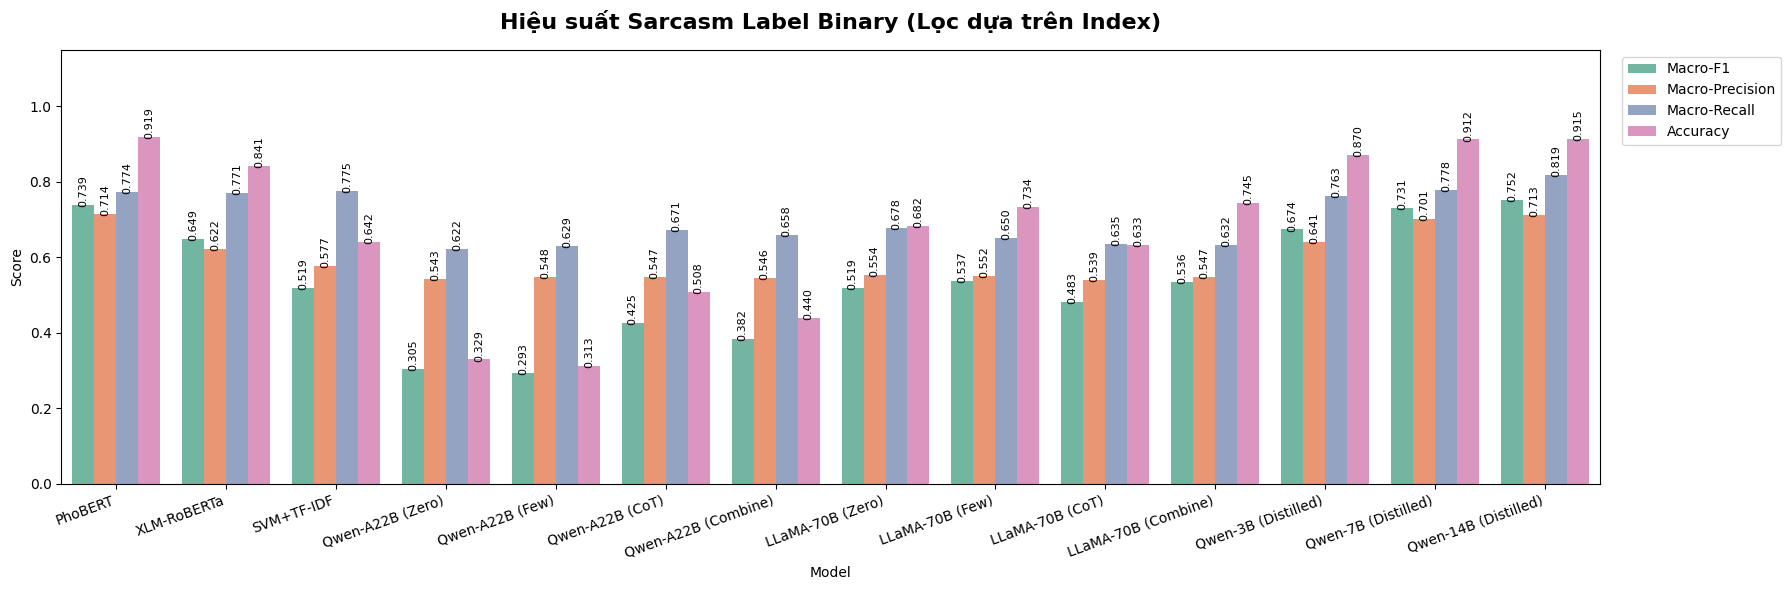


 BÁO CÁO ĐÁNH GIÁ: SARCASM TYPE MULTI-CLASS (N=787)
               Model  Accuracy  Macro-F1  Macro-Precision  Macro-Recall
             PhoBERT  0.899619  0.420763         0.400240      0.547498
         XLM-RoBERTa  0.809403  0.222541         0.210132      0.312526
          SVM+TF-IDF  0.607370  0.279254         0.263864      0.558957
    Qwen-A22B (Zero)  0.290978  0.139280         0.202125      0.500797
     Qwen-A22B (Few)  0.269377  0.126177         0.198688      0.450584
     Qwen-A22B (CoT)  0.481576  0.220036         0.227740      0.528849
 Qwen-A22B (Combine)  0.410419  0.151761         0.180262      0.394134
    LLaMA-70B (Zero)  0.645489  0.166073         0.179889      0.223504
     LLaMA-70B (Few)  0.711563  0.193457         0.200438      0.249682
     LLaMA-70B (CoT)  0.601017  0.145301         0.169729      0.205834
 LLaMA-70B (Combine)  0.726811  0.216312         0.223386      0.266086
 Qwen-3B (Distilled)  0.861499  0.411439         0.354325      0.595078
 Qwen-7B (D

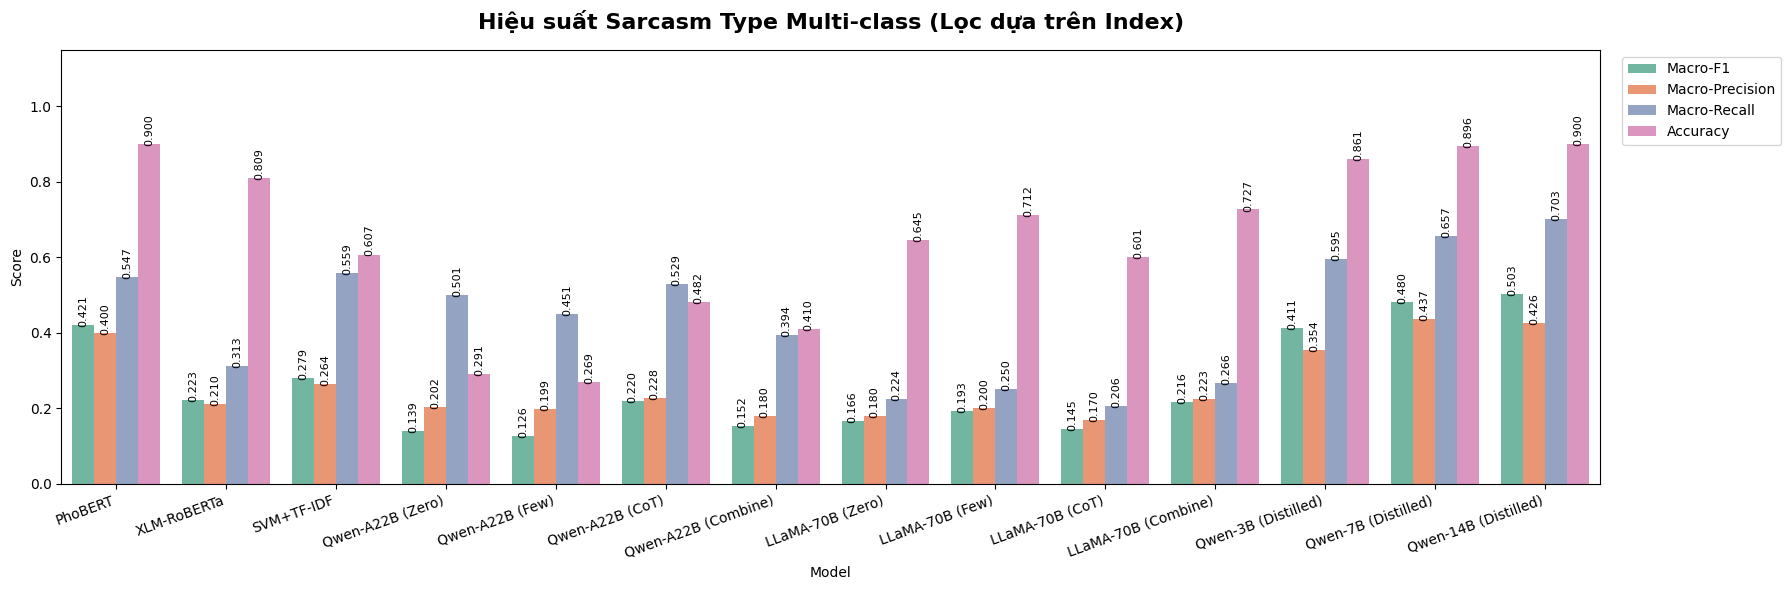

In [5]:
def evaluate_task(y_true, predictions_dict, task_name):
    results = []
    for model_name, y_pred in predictions_dict.items():
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
        
        results.append({
            "Model": model_name,
            "Accuracy": acc,
            "Macro-F1": f1_macro,
            "Macro-Precision": prec_macro,
            "Macro-Recall": rec_macro
        })
        
    df_report = pd.DataFrame(results)
    
    print(f"\n{'='*70}")
    print(f" BÁO CÁO ĐÁNH GIÁ: {task_name.upper()} (N={len(y_true)})")
    print(f"{'='*70}")
    print(df_report.to_string(index=False))
    
    # Vẽ Barplot
    plt.figure(figsize=(18, 6))
    df_melted = df_report.melt(id_vars=["Model"], value_vars=["Macro-F1", "Macro-Precision", "Macro-Recall", "Accuracy"], 
                               var_name="Metric", value_name="Score")
    
    ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="Set2")
    plt.title(f"Hiệu suất {task_name} (Lọc dựa trên Index)", fontsize=16, fontweight='bold', pad=15)
    plt.ylim(0, 1.15)
    plt.xticks(rotation=20, ha='right')
    
    # Annotation
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format(height, '.3f'), (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8, rotation=90)
            
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"benchmark_{task_name.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()
    
    return df_report

# Chạy đánh giá cho 2 tác vụ
report_label = evaluate_task(y_true_label, predictions_label, "Sarcasm Label Binary")
report_type = evaluate_task(y_true_type, predictions_type, "Sarcasm Type Multi-class")

# (Tùy chọn) Lưu ra CSV
report_label.to_csv('final_report_sarcasm_label.csv', index=False)
report_type.to_csv('final_report_sarcasm_type.csv', index=False)

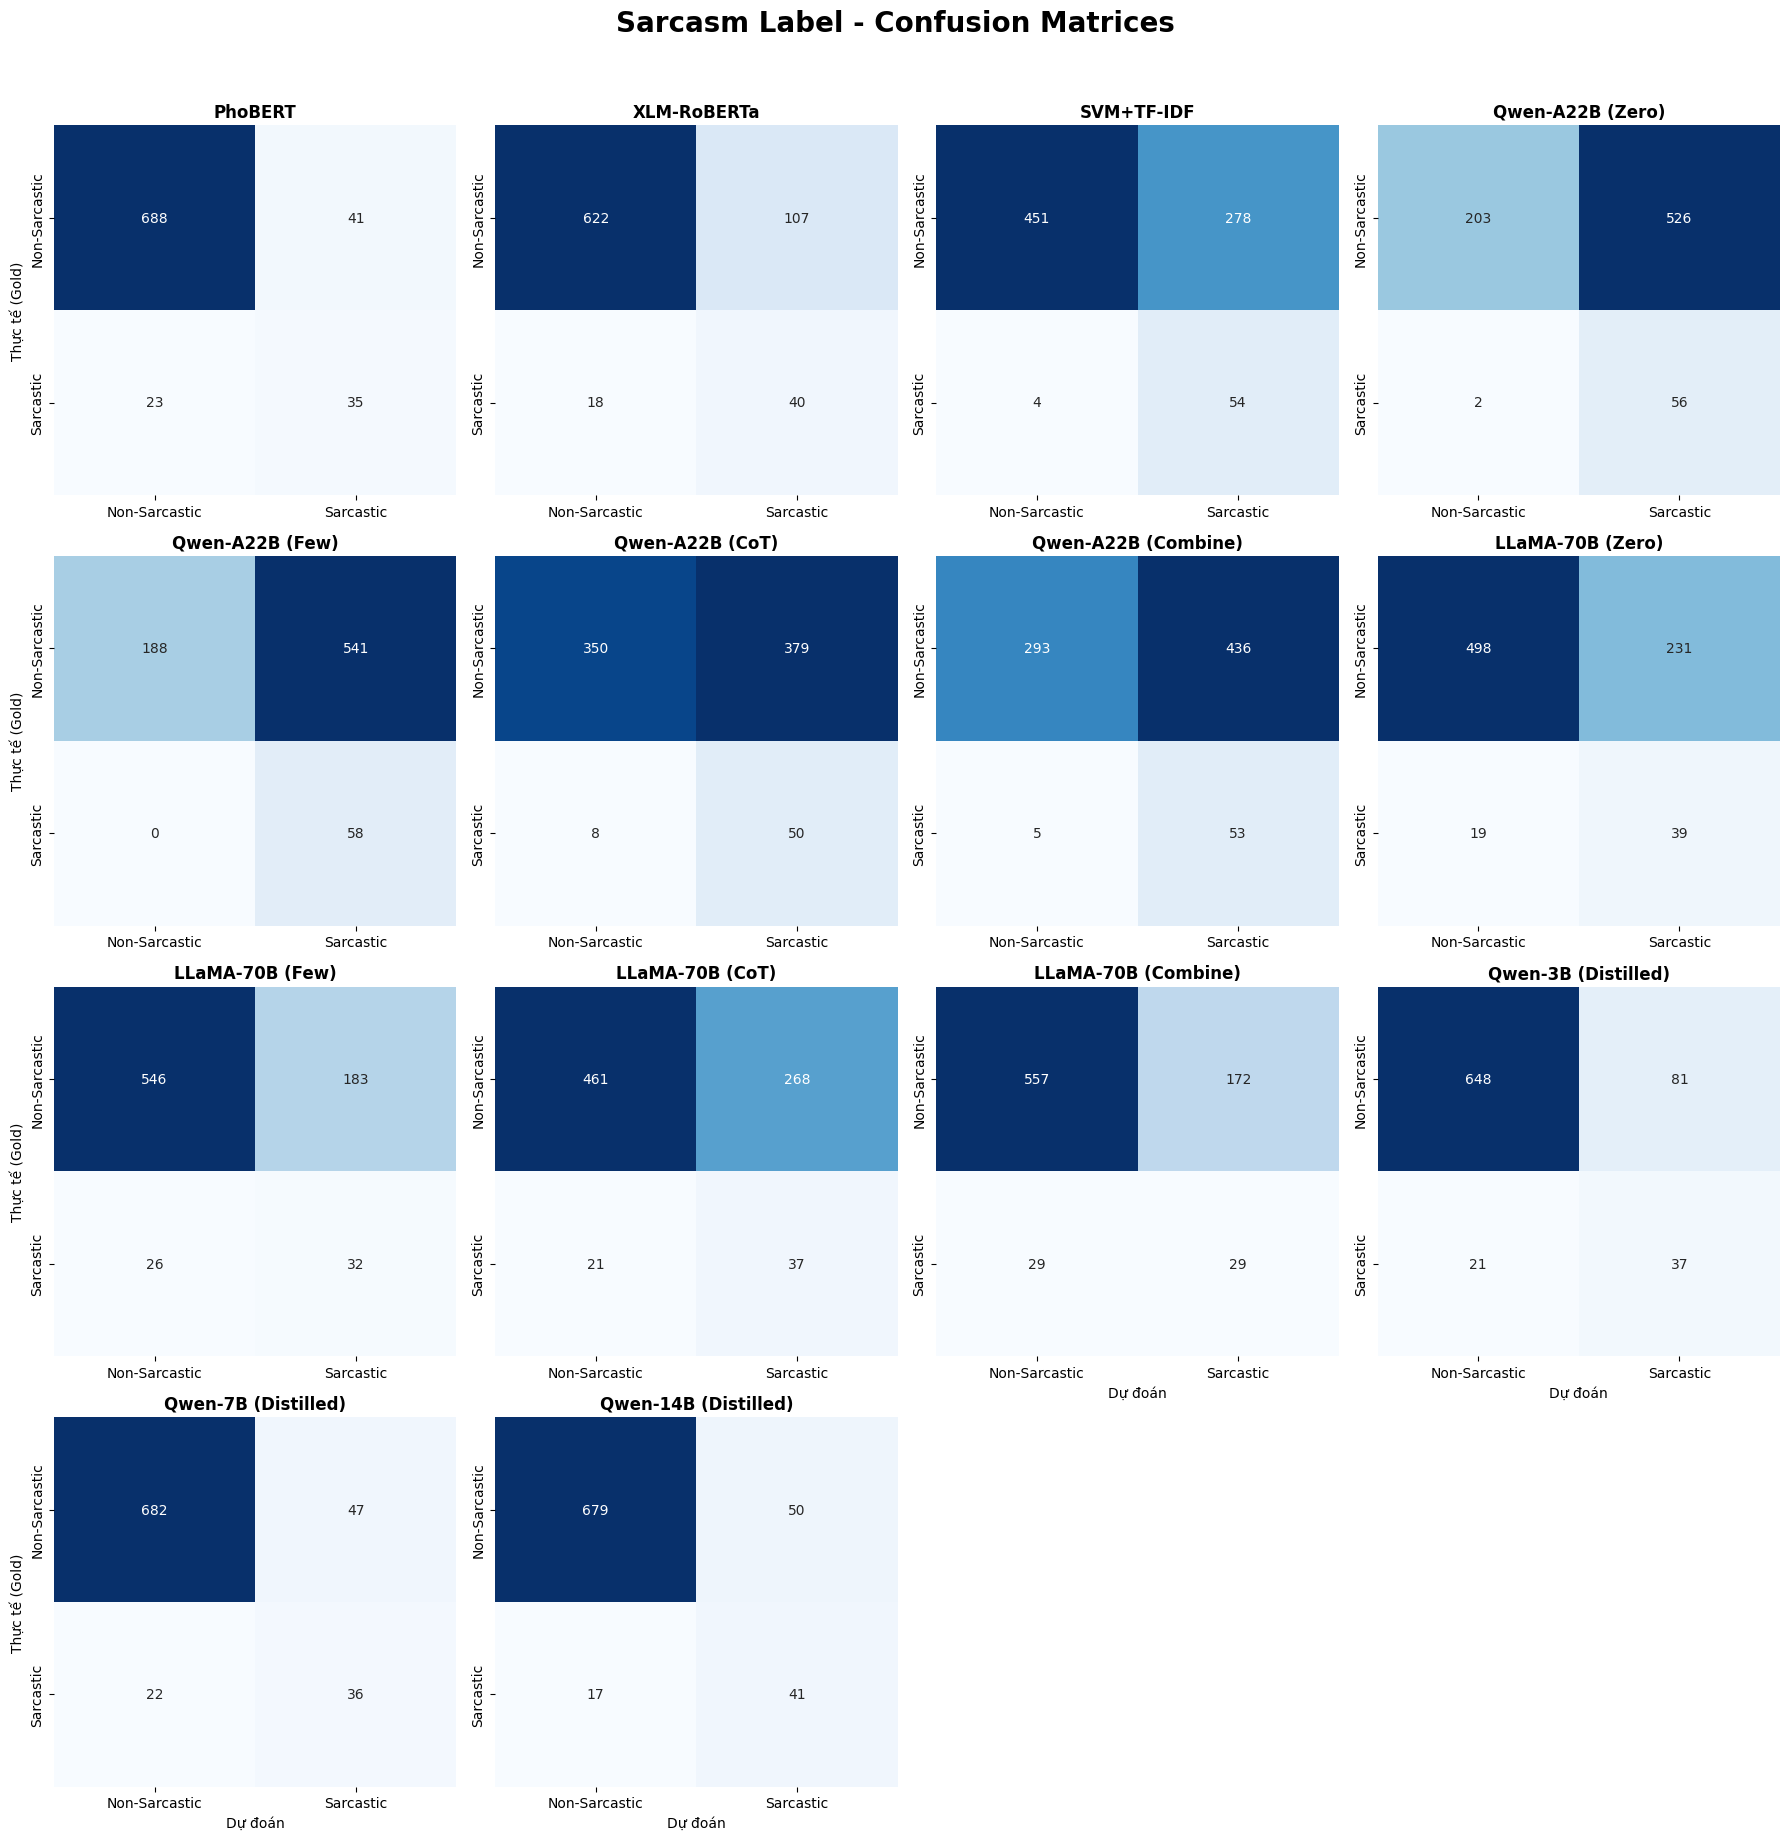

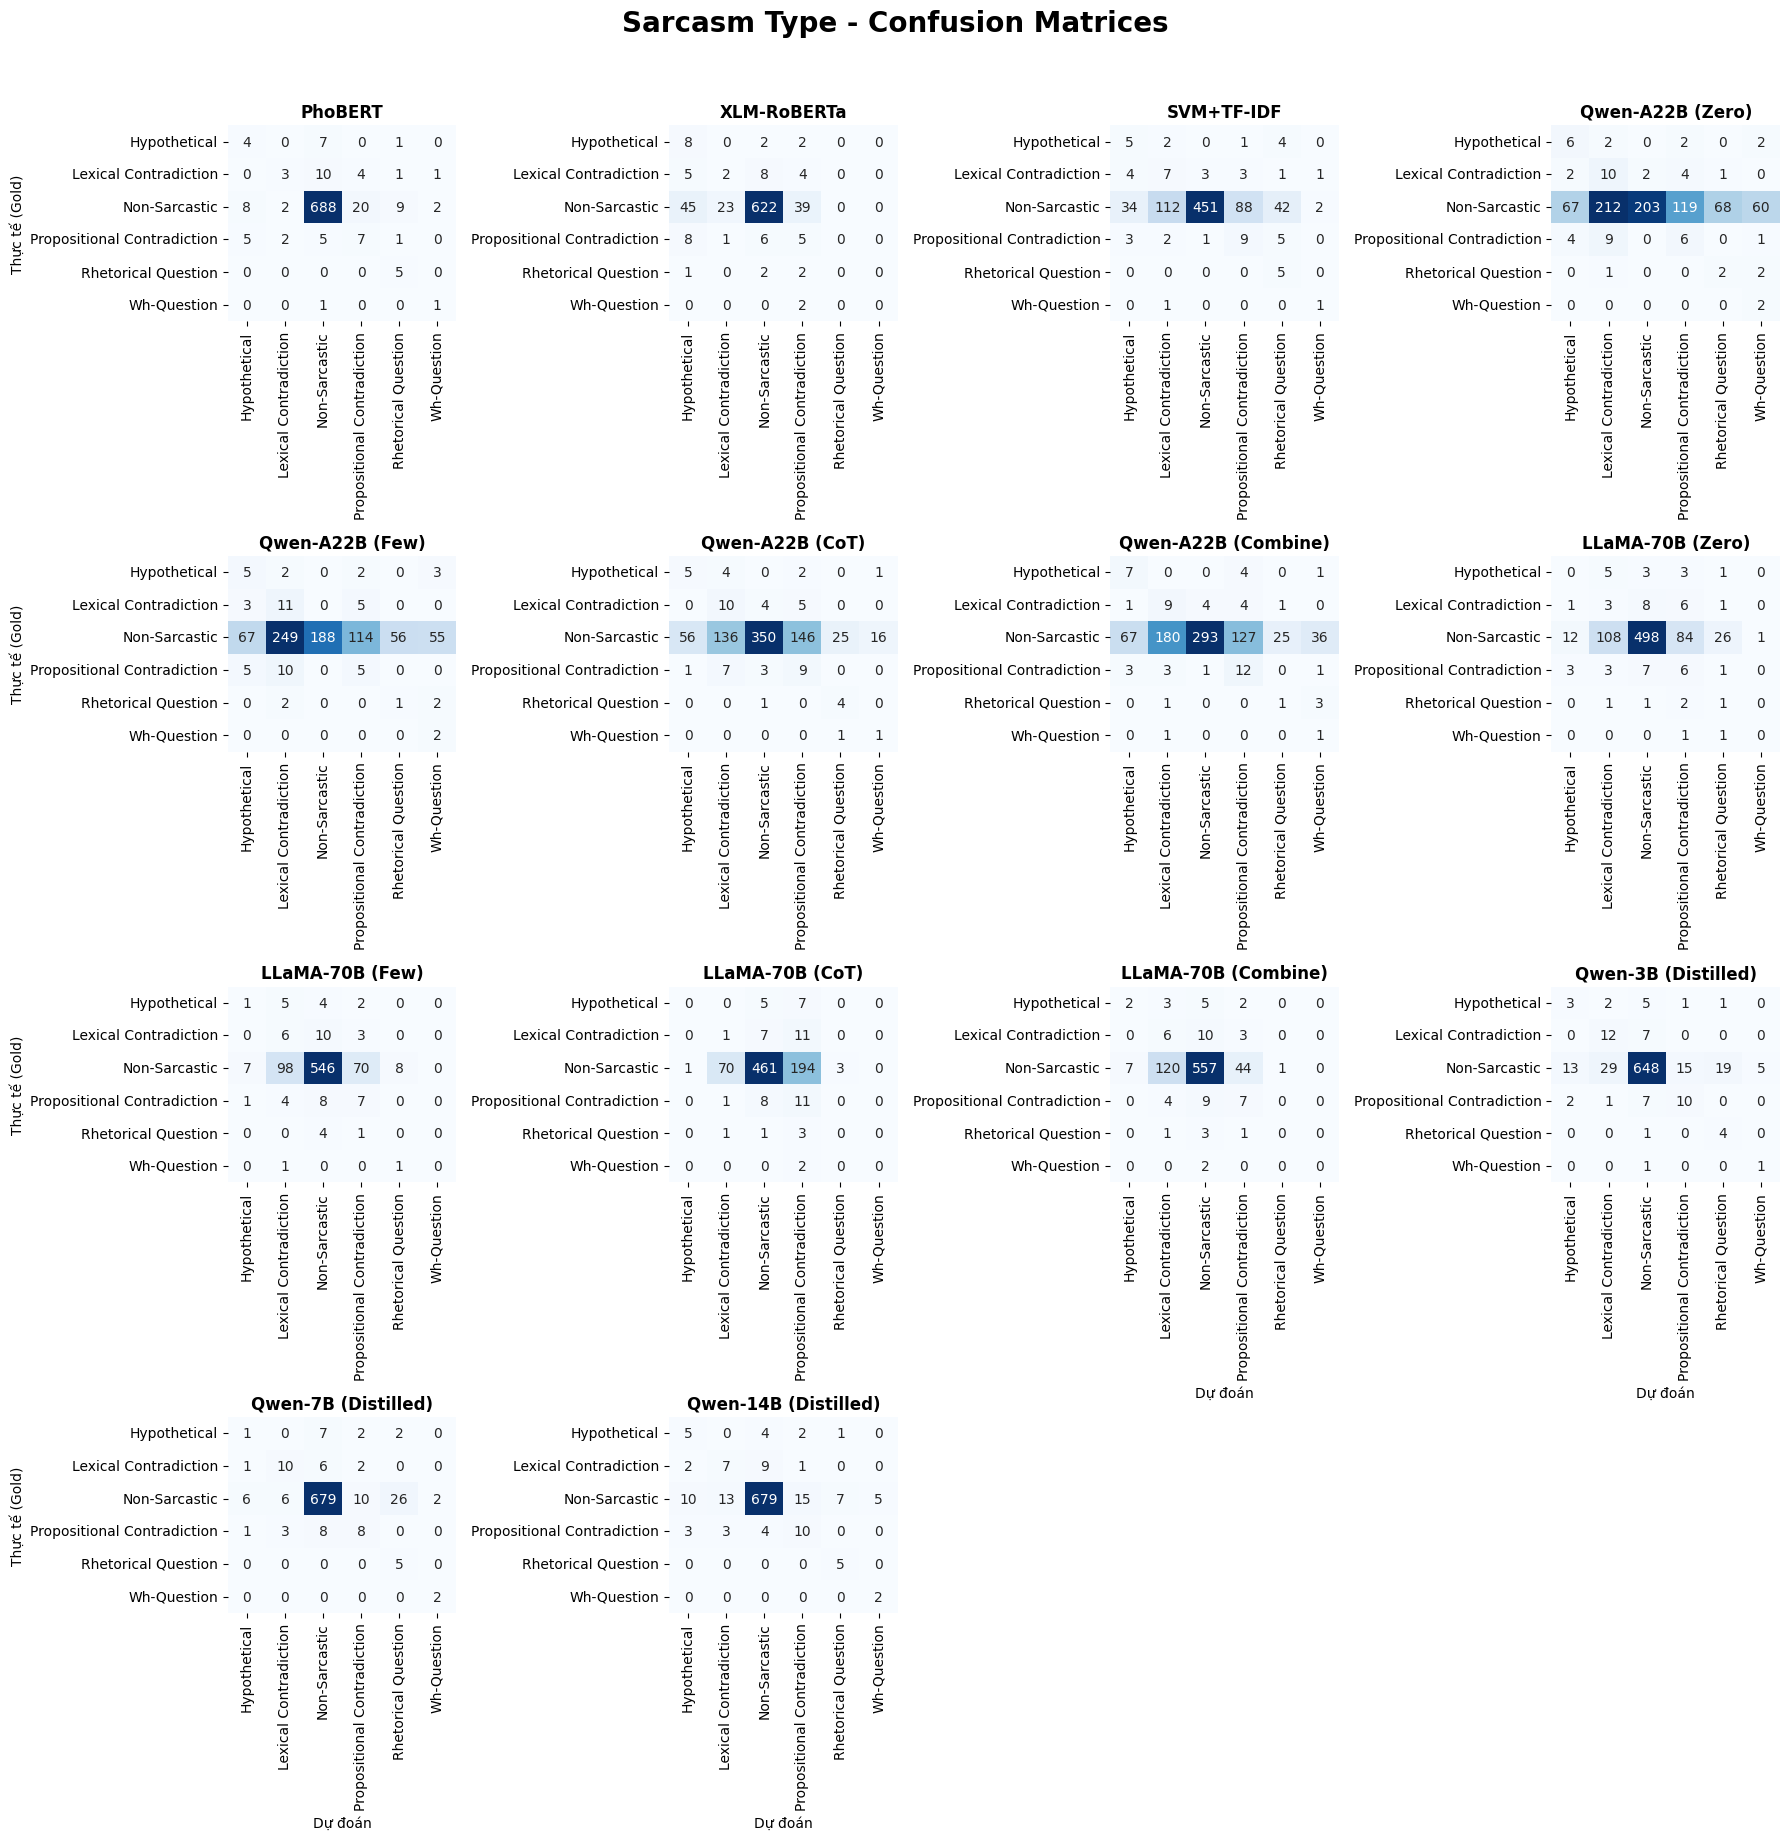

In [6]:
def plot_all_confusion_matrices(y_true, predictions_dict, title_prefix, file_name):
    # Lấy danh sách các class xuất hiện thực tế và dự đoán để vẽ trục cho chuẩn
    labels_list = sorted(list(set(y_true)))
    
    num_models = len(predictions_dict)
    cm_cols = 4
    cm_rows = (num_models + cm_cols - 1) // cm_cols
    
    fig = plt.figure(figsize=(18, 4.5 * cm_rows))
    gs = fig.add_gridspec(cm_rows, cm_cols)
    
    for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
        row = i // cm_cols
        col = i % cm_cols
        ax_cm = fig.add_subplot(gs[row, col])
        
        cm = confusion_matrix(y_true, y_pred, labels=labels_list)
        sns.heatmap(cm, annot=True, fmt='g', cmap="Blues", cbar=False, 
                    xticklabels=labels_list, yticklabels=labels_list, ax=ax_cm)
        
        ax_cm.set_title(f"{model_name}", fontsize=12, fontweight='bold')
        if row == cm_rows - 1 or i >= num_models - cm_cols: # Hàng cuối
            ax_cm.set_xlabel('Dự đoán')
        if col == 0:
            ax_cm.set_ylabel('Thực tế (Gold)')
            
    plt.suptitle(f"{title_prefix} - Confusion Matrices", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

# Xuất ảnh confusion matrices cho Label và Type
plot_all_confusion_matrices(y_true_label, predictions_label, "Sarcasm Label", "cm_sarcasm_label.png")
plot_all_confusion_matrices(y_true_type, predictions_type, "Sarcasm Type", "cm_sarcasm_type.png")


 🏆 SO SÁNH NỘI BỘ THEO NHÓM PHƯƠNG PHÁP: SARCASM LABEL BINARY
       Method_Group                Model  Macro-F1  Macro-Precision  Macro-Recall  Accuracy
       Distillation Qwen-14B (Distilled)  0.751659         0.713062      0.819155  0.914867
       Distillation  Qwen-7B (Distilled)  0.731244         0.701242      0.778109  0.912325
       Distillation  Qwen-3B (Distilled)  0.673747         0.641085      0.763410  0.870394
   Prompting (LLMs)      LLaMA-70B (Few)  0.536893         0.551691      0.650348  0.734435
   Prompting (LLMs)  LLaMA-70B (Combine)  0.535543         0.547395      0.632030  0.744600
   Prompting (LLMs)     LLaMA-70B (Zero)  0.518581         0.553847      0.677771  0.682338
   Prompting (LLMs)      LLaMA-70B (CoT)  0.482606         0.538872      0.635152  0.632783
   Prompting (LLMs)      Qwen-A22B (CoT)  0.424657         0.547102      0.671089  0.508259
   Prompting (LLMs)  Qwen-A22B (Combine)  0.382189         0.545803      0.657857  0.439644
   Prompting (LLM

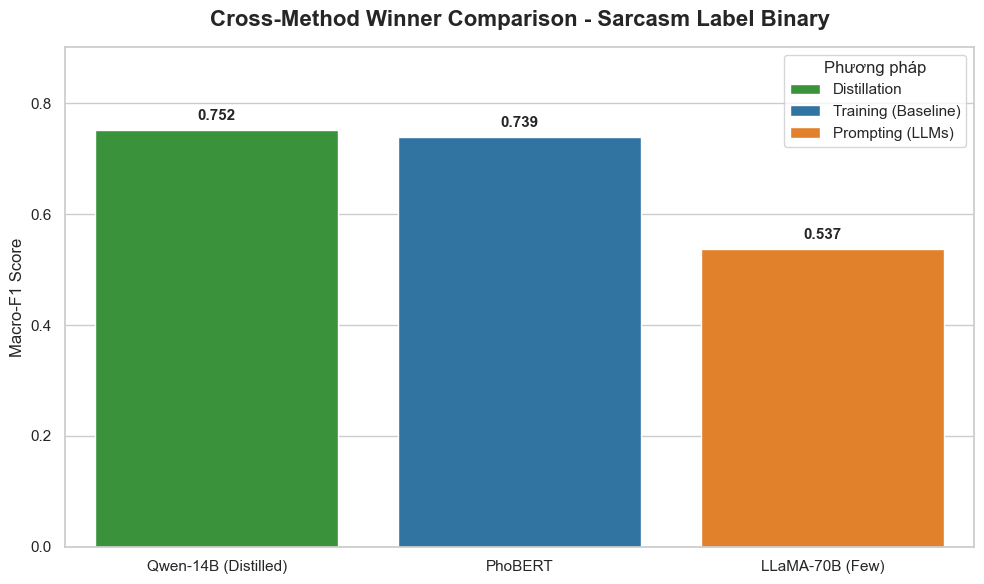


 🏆 SO SÁNH NỘI BỘ THEO NHÓM PHƯƠNG PHÁP: SARCASM TYPE MULTI-CLASS
       Method_Group                Model  Macro-F1  Macro-Precision  Macro-Recall  Accuracy
       Distillation Qwen-14B (Distilled)  0.502580         0.426233      0.702750  0.899619
       Distillation  Qwen-7B (Distilled)  0.480441         0.437096      0.656844  0.895807
       Distillation  Qwen-3B (Distilled)  0.411439         0.354325      0.595078  0.861499
   Prompting (LLMs)      Qwen-A22B (CoT)  0.220036         0.227740      0.528849  0.481576
   Prompting (LLMs)  LLaMA-70B (Combine)  0.216312         0.223386      0.266086  0.726811
   Prompting (LLMs)      LLaMA-70B (Few)  0.193457         0.200438      0.249682  0.711563
   Prompting (LLMs)     LLaMA-70B (Zero)  0.166073         0.179889      0.223504  0.645489
   Prompting (LLMs)  Qwen-A22B (Combine)  0.151761         0.180262      0.394134  0.410419
   Prompting (LLMs)      LLaMA-70B (CoT)  0.145301         0.169729      0.205834  0.601017
   Prompting 

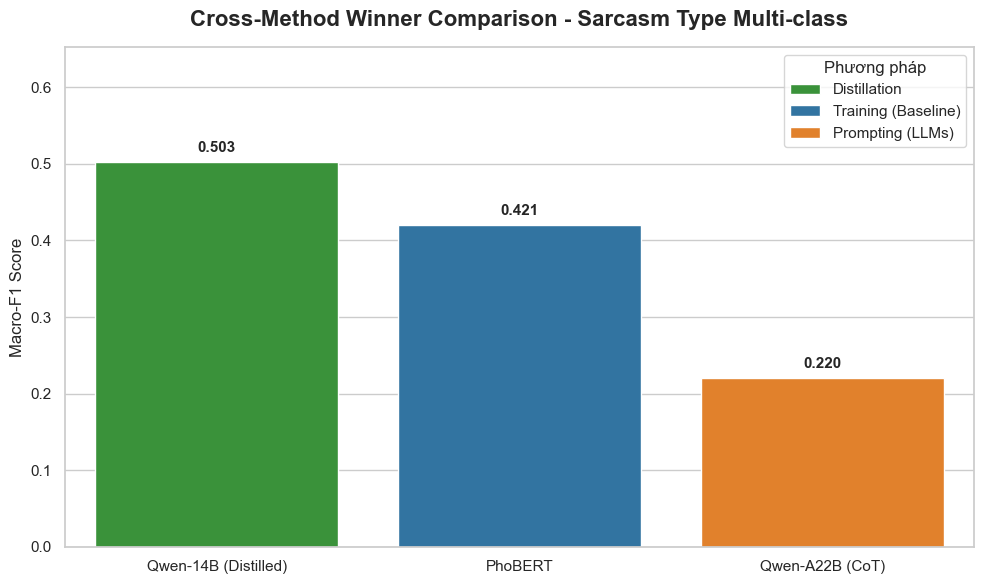

In [7]:
# Dictionary gán nhãn nhóm phương pháp
METHOD_GROUPS = {
    "PhoBERT": "Training (Baseline)", "XLM-RoBERTa": "Training (Baseline)", "SVM+TF-IDF": "Training (Baseline)",
    "Qwen-A22B (Zero)": "Prompting (LLMs)", "Qwen-A22B (Few)": "Prompting (LLMs)", 
    "Qwen-A22B (CoT)": "Prompting (LLMs)", "Qwen-A22B (Combine)": "Prompting (LLMs)",
    "LLaMA-70B (Zero)": "Prompting (LLMs)", "LLaMA-70B (Few)": "Prompting (LLMs)", 
    "LLaMA-70B (CoT)": "Prompting (LLMs)", "LLaMA-70B (Combine)": "Prompting (LLMs)",
    "Qwen-3B (Distilled)": "Distillation", "Qwen-7B (Distilled)": "Distillation", "Qwen-14B (Distilled)": "Distillation"
}

def analyze_and_compare_methods(df_report, task_name):
    # Gán Group cho dataframe
    df_report['Method_Group'] = df_report['Model'].map(METHOD_GROUPS)
    
    # ---------------------------------------------------------
    # 1. SO SÁNH NỘI BỘ (Sắp xếp theo Nhóm và Macro-F1 giảm dần)
    # ---------------------------------------------------------
    df_internal = df_report.sort_values(by=['Method_Group', 'Macro-F1'], ascending=[True, False])
    file_internal = f"comparison_internal_{task_name.replace(' ', '_').lower()}.csv"
    df_internal.to_csv(file_internal, index=False)
    
    print(f"\n{'='*85}")
    print(f" 🏆 SO SÁNH NỘI BỘ THEO NHÓM PHƯƠNG PHÁP: {task_name.upper()}")
    print(f"{'='*85}")
    print(df_internal[['Method_Group', 'Model', 'Macro-F1', 'Macro-Precision', 'Macro-Recall', 'Accuracy']].to_string(index=False))
    
    # ---------------------------------------------------------
    # 2. SO SÁNH MÔ HÌNH TỐT NHẤT TỪNG NHÓM (Cross-Method)
    # ---------------------------------------------------------
    # Tìm index của mô hình có F1 cao nhất trong mỗi nhóm
    idx_best = df_report.groupby('Method_Group')['Macro-F1'].idxmax()
    df_best = df_report.loc[idx_best].sort_values(by='Macro-F1', ascending=False)
    
    file_best = f"comparison_best_cross_method_{task_name.replace(' ', '_').lower()}.csv"
    df_best.to_csv(file_best, index=False)
    
    print(f"\n{'='*85}")
    print(f" 🥇 CÁC MÔ HÌNH TỐT NHẤT ĐẠI DIỆN CHO TỪNG PHƯƠNG PHÁP: {task_name.upper()}")
    print(f"{'='*85}")
    print(df_best[['Method_Group', 'Model', 'Macro-F1', 'Macro-Precision', 'Macro-Recall', 'Accuracy']].to_string(index=False))
    
    # ---------------------------------------------------------
    # 3. TRỰC QUAN HÓA (Biểu đồ so sánh Top Models)
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Cấu hình màu cho 3 phương pháp để dễ phân biệt
    palette = {"Training (Baseline)": "#1f77b4", "Prompting (LLMs)": "#ff7f0e", "Distillation": "#2ca02c"}
    
    ax = sns.barplot(data=df_best, x='Model', y='Macro-F1', hue='Method_Group', dodge=False, palette=palette)
    plt.title(f"Cross-Method Winner Comparison - {task_name}", fontsize=16, fontweight='bold', pad=15)
    plt.ylim(0, max(df_best['Macro-F1']) + 0.15)
    plt.xlabel("")
    plt.ylabel("Macro-F1 Score", fontsize=12)
    
    # Thêm giá trị lên đỉnh cột
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format(height, '.3f'), (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11, fontweight='bold')
            
    plt.legend(title="Phương pháp", loc='upper right')
    plt.tight_layout()
    plt.savefig(f"best_cross_method_{task_name.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()

# Thực thi phân tích cho cả 2 tác vụ
analyze_and_compare_methods(report_label, "Sarcasm Label Binary")
analyze_and_compare_methods(report_type, "Sarcasm Type Multi-class")